# Images

#### Telecopes and detectors produce images 

#### We have arrays of pixel values, not lists of celestial objects 

#### How do we identify objects in the catalogues?

#### We look for groups of pixels that differ significantly from the background

#### We look for groups of pixels that have the right shape (i.e. blurred by the optics and atmosphere)

#### We want consistent identification of objects - automated rather than by eye

#### 

# Segmentation 

#### Identify pixels that meet a signal to noise threshold

#### Connect pixels together and create objects when the number of pixels is above some threshold

#### Can identify objects with somewhat arbitrary shapes 

#### Can struggle with diffuse objects where individual pixels may not be above the noise 

####

In [1]:
# Import various libraries 

import numpy as np
import astropy
import photutils
import ccdproc
from ccdproc import CCDData, combiner
from astropy import units as u
import astropy.io.fits as fits
from astropy.io import ascii
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from photutils.centroids import centroid_com, centroid_1dg, centroid_2dg
from photutils.aperture import CircularAperture
from photutils.aperture import aperture_photometry
from photutils.background import Background2D
from photutils.background import MedianBackground
from photutils.detection import DAOStarFinder
from photutils.segmentation  import detect_sources, deblend_sources, SourceCatalog
from scipy.ndimage import shift
import gc                               

from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia


The archive is unstable and may perform below expectations. Please avoid launching intense Python query showers. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the recent infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
[-162.4076645    59.07871393  238.25161333 ...  -42.50134027   25.78018856
   29.92168301]


Set OBSGEO-Y to  2879792.379 from OBSGEO-[LBH].
Set OBSGEO-Z to -3897419.410 from OBSGEO-[LBH]'. [astropy.wcs.wcs]


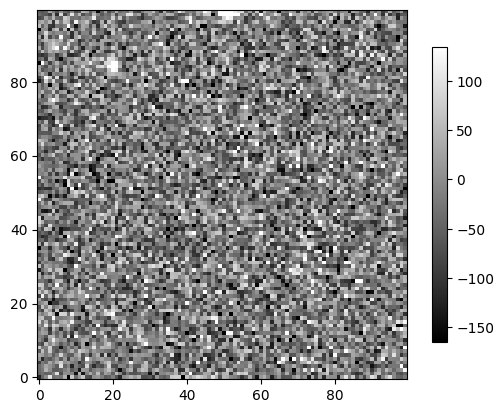

In [2]:
fn='NGC_3293_V_median_wcs.fits'
science_im=CCDData.read(fn, unit = "adu")                           

skydata=science_im.data
print(skydata[0])
skydata=science_im.data[1030:1130,60:160]
p1=np.nanpercentile(skydata, 1)
p99=np.nanpercentile(skydata, 99)
plt.imshow(skydata, cmap='gray', vmin=p1, vmax=p99)
ax = plt.gca()
ax.invert_yaxis()
plt.colorbar(shrink=0.8)



In [3]:
# Lets run stats on some of this data to get the background and noise

med=np.nanmedian(skydata)
print('Median:', med)

std=np.nanstd(skydata)
print('Standard deviation:', std)


Median: -19.629855165306957
Standard deviation: 63.77490965876932


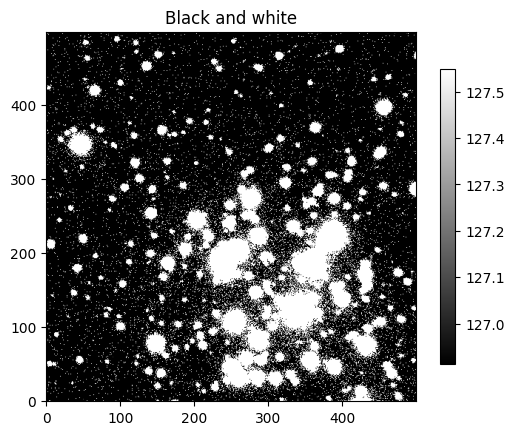

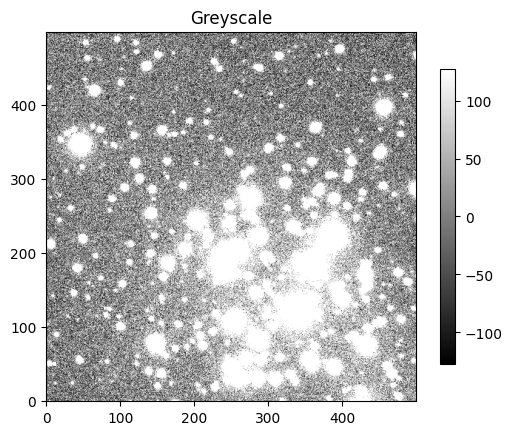

In [4]:
# Lets display the image with 2-simga corresponding to white 

#skydata=science_im.data
skydata=science_im.data[500:1000,500:1000]
p1=np.nanpercentile(skydata, 1)
p99=np.nanpercentile(skydata, 99)
plt.imshow(skydata, cmap='gray', vmin=1.99*std, vmax=2*std)
ax = plt.gca()
ax.invert_yaxis()
plt.colorbar(shrink=0.8)
plt.title('Black and white')
plt.show()

p1=np.nanpercentile(skydata, 1)
p99=np.nanpercentile(skydata, 99)
plt.imshow(skydata, cmap='gray', vmin=-2.0*std, vmax=2.0*std)
ax = plt.gca()
ax.invert_yaxis()
plt.colorbar(shrink=0.8)
plt.title('Greyscale')
plt.show()



# Segmentation image 

In [5]:
segimage=detect_sources(science_im.data, 2.00*std, 9, connectivity=4, mask=None)
print('Segmentation image minimum:', np.min(segimage.data))
print('Segmentation image maximum:', np.max(segimage.data))


Segmentation image minimum: 0
Segmentation image maximum: 1301


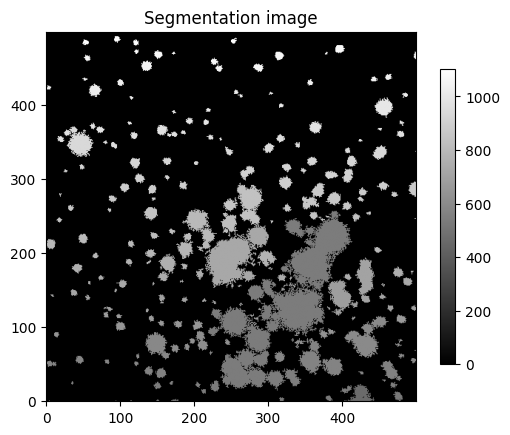

In [6]:
skydata=segimage[500:1000,500:1000]
plt.imshow(skydata, cmap='gray')
ax = plt.gca()
ax.invert_yaxis()
plt.colorbar(shrink=0.8)
plt.title('Segmentation image')
plt.show()


In [7]:
outfile="segimage.fits"                # Set the output file name
hdu=fits.PrimaryHDU(segimage)          # Define a FITS header for this data
hdu.writeto(outfile, overwrite=True)   # Write the output and overwrite existing files if needed. 


# What do the pixel values in the segmentation image correspond to?

# Read the world coordinate system


In [8]:
w = science_im.wcs
print(w)


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP'
CUNIT : 'deg' 'deg'
CRVAL : 158.955343907 -58.2320832016
CRPIX : 837.582138062 660.975112915
CD1_1 CD1_2  : -0.000214357182677 -1.81647414026e-05
CD2_1 CD2_2  : 1.81390957336e-05 -0.000214261763096
NAXIS : 1679  1268


# Convert the segmentation image into a catalogue

In [9]:
source_table=SourceCatalog(science_im.data, segimage, error=None, mask=None, background=None, wcs=w)
print('Source table length:\n', len(source_table))
print('\n\n')
print('First entry centroid x and y values :') 
print(source_table[0].centroid[0], source_table[0].centroid[1])
print('\n\n')
print('First source sky icrs coordinates :') # 
print(source_table[0].sky_centroid_icrs)
print(source_table[0].sky_centroid_icrs.ra, source_table[0].sky_centroid_icrs.dec)


Source table length:
 1301



First entry centroid x and y values :
194.01314681779434 2.195742420363557



First source sky icrs coordinates :
<SkyCoord (ICRS): (ra, dec) in deg
    (159.23850837, -58.10246234)>
159d14m18.63014455s -58d06m08.86441301s


# Define positions for photometry 

In [10]:
positions = []   

for star in source_table:
    positions.append((star.centroid[0], star.centroid[1]))
print(positions[0:10]) # delete 
# Comment on this
apertures = CircularAperture(positions, r=20.0)


[(np.float64(194.01314681779434), np.float64(2.195742420363557)), (np.float64(369.2529828457113), np.float64(0.7818336216333804)), (np.float64(680.7818038333247), np.float64(9.723645295664113)), (np.float64(57.590963366473105), np.float64(5.461946156741536)), (np.float64(222.11135319011098), np.float64(5.64536074845634)), (np.float64(6.284936204103665), np.float64(6.396270234646238)), (np.float64(1335.0937763167747), np.float64(8.473654948924983)), (np.float64(443.72342931773863), np.float64(8.720142677336451)), (np.float64(99.32073255212254), np.float64(10.129594898928223)), (np.float64(174.22004144612262), np.float64(8.563396976654742))]


# Measure photometry 

In [11]:
phot_table = aperture_photometry(science_im, apertures)
print(phot_table)

 id       xcenter       ...     aperture_sum   
                        ...         adu        
---- ------------------ ... -------------------
   1 194.01314681779434 ...   50233.95051673803
   2  369.2529828457113 ...  127423.11465273655
   3  680.7818038333247 ...  114403.57524980164
   4 57.590963366473105 ... -24972.930133414367
   5 222.11135319011098 ... -21761.399692372215
   6  6.284936204103665 ...  30783.546901216894
   7 1335.0937763167747 ...   84333.83336048169
   8 443.72342931773863 ... -25555.749962320395
   9  99.32073255212254 ...                 nan
 ...                ... ...                 ...
1292  818.3291220836808 ...  5599.2922976004165
1293  1355.174538001279 ...  159256.18778677756
1294 476.21789685343083 ...   7252.792023145424
1295 392.94014823046166 ...  3897.2323446815226
1296 1120.3395164505696 ...  -489.9156364936589
1297  1648.019058933064 ... -22462.275025247523
1298 344.83901566929717 ...  31902.628809908332
1299  942.6932514761843 ...   2457.38911

# Gaia query for a star 

#### I found this star using the science image and the segmentation image - how?

In [13]:
idx=951-1
print(phot_table[idx])
print(source_table[idx].sky_centroid_icrs.ra, source_table[idx].sky_centroid_icrs.dec)

rad=float(source_table[idx].sky_centroid_icrs.ra.value)
decd=float(source_table[idx].sky_centroid_icrs.dec.value)
print(rad,decd)
# Get coordinates in astropy format
coord = SkyCoord(ra=rad, dec=decd, unit=(u.degree, u.degree), frame='icrs')
# Match radius in degrees
radius = u.Quantity(0.001, u.deg)
# Run query and return results
j = Gaia.cone_search_async(coord, radius=radius)
r = j.get_results()
if len(r)>0:
    print('Gaia BP mag: ', r[0]['phot_bp_mean_mag'])
    print('Gaia G  mag: ', r[0]['phot_g_mean_mag'])
    print('Gaia RP mag: ', r[0]['phot_rp_mean_mag'])
    gmag=[r[0]['phot_bp_mean_mag'], r[0]['phot_g_mean_mag'], r[0]['phot_rp_mean_mag']]
    

 id      xcenter            ycenter                    sky_center                 aperture_sum   
                                                        deg,deg                       adu        
--- ------------------ ----------------- ------------------------------------- ------------------
951 1118.4877260577375 848.0574234381355 158.83393847927078,-58.26720952123292 153267.68616894918
158d50m02.13092994s -58d16m01.93860501s
158.8339252583162 -58.26720516805707
INFO: Query finished. [astroquery.utils.tap.core]
Gaia BP mag:  13.003108
Gaia G  mag:  12.907821
Gaia RP mag:  12.736545


# Determine V-band magnitude for this star and zeropoint

#### Here we are using one star in our image to get the zeropoint. It is better in practice to use multiple stars. 

#### Blue stars are best for measuring the zeropoint as they have a small colour term

In [14]:
# Gaia-V relation from an earlier notebook 
Vpoly = [0.4438681, 0.26560882, 0.0039465 ]

V = gmag[1] + Vpoly[0]*(gmag[0]-gmag[1])**2 + Vpoly[1]*(gmag[0]-gmag[1]) + Vpoly[2]

print('V mag: ', V)

zp = V + 2.5*np.log10(phot_table[idx]['aperture_sum'].value)
print('Zeropoint: ', zp) 

V mag:  12.941107
Zeropoint:  25.904733298896453


# Determine photometry for all the other objects 

\begin{equation}
m = zp - 2.5 {\rm log} ( F)
\end{equation}

In [15]:
Vmags=[]
for phot in phot_table['aperture_sum']:
    Vmags.append(zp-2.5*np.log10(phot.value))

print('Example V-band magnitudes') 
print(Vmags[100:120])

Example V-band magnitudes
[np.float64(12.473987256446913), np.float64(nan), np.float64(16.42824174353504), np.float64(14.417532459298473), np.float64(17.950506026971183), np.float64(nan), np.float64(nan), np.float64(13.57918481816879), np.float64(15.813565542076883), np.float64(11.238889834756172), np.float64(nan), np.float64(nan), np.float64(17.80842922376818), np.float64(17.071511862716967), np.float64(nan), np.float64(16.618112393151797), np.float64(nan), np.float64(nan), np.float64(12.649192201833063), np.float64(13.004419767130798)]


C:\Users\stanl\AppData\Local\Temp\ipykernel_54264\2474358575.py:3: RuntimeWarning: invalid value encountered in log10
  Vmags.append(zp-2.5*np.log10(phot.value))


# Model

#### We can identify pixels with values consistent with a model 

#### At each pixel we fit the model light distribution of a star to the data 

#### Peaks will occur at the positons of stars (or peaks in the noise too)

#### Individual pixels do not have to meet a signal-to-noise threshold 

####

# Model fitting

Consider fitting a model to the data (for example, a 2D Gaussain) - $f(x,y)$

We could also normalise this model so 

\begin{equation}
\int \int f(x,y) dx dy = 1
\end{equation}

At every pixel we can try to fit the model to the data, with peaks in the model corresponding to objects

\begin{equation}
\chi ^2 = \sum_i  \frac{(d(x_i,y_i) - A f(x_i,y_i))^2} {\sigma_i^2}
\end{equation}

\begin{equation}
\chi ^2 = \sum_i  \frac{d(x_i,y_i)^2 - 2 A d(x_i,y_i) f(x_i,y_i) + A^2 f(x_i,y_i)^2 } {\sigma_i^2}
\end{equation}

where $A$ is a scaling factor, $d(x,y)$ is the data (i.e. counts) and $\sigma$ is the noise. 

The best fit value of A can be found by taking the derivative of this model and finding when the derivative equals zero.

\begin{equation}
0 = \frac{d\chi ^2}{dA} = \sum_i  \frac{ - 2 d(x_i,y_i) f(x_i,y_i) + 2 A f(x_i,y_i)^2 } {\sigma_i^2}
\end{equation}

\begin{equation}
 \sum_i  \frac{ 2 d(x_i,y_i) f(x_i,y_i)} {\sigma_i^2} = \sum_i  \frac{ + 2 A f(x_i,y_i)^2 } {\sigma_i^2}
\end{equation}

\begin{equation}
 \sum_i  \frac{ d(x_i,y_i) f(x_i,y_i)} {\sigma_i^2} = A \sum_i  \frac{ f(x_i,y_i)^2 } {\sigma_i^2}
\end{equation}

\begin{equation}
A = \sum_i  \frac{ d(x_i,y_i) f(x_i,y_i)} {\sigma_i^2} \div \sum_i  \frac{ f(x_i,y_i)^2 } {\sigma_i^2}
\end{equation}

If we find the pixels where $A$ peaks then these peaks will correspond to objects (at least when they are significantly above the background).

If the noise is approximately uniform across the image then the equation can be simplified, and one is effectively just multiplying the 2D data with the 2D model (i.e. a convolution).

Also, if the model is a good approximation of the data then $A$ is equal to the object flux. 

DAOStarFinder and IRAFStarFinder in astropy both use this approach.